In [1]:
import pandas as pd
import numpy as np
import os
import math

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from scipy.stats import pearsonr
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

import geopandas as gpd
from shapely.geometry import Point
from geopandas import GeoDataFrame
from geopy.distance import geodesic
from datetime import date, timedelta

from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from datetime import date, timedelta
from collections import defaultdict

from scipy.stats import genextreme
import warnings

warnings.filterwarnings('ignore')

In [13]:
gridmet_data = pd.read_csv("/Users/guptsh/Downloads/Soil_Land_Crop/datasets/gridMET_data/gridMET.csv")
yield_data = pd.read_csv("/Users/guptsh/Downloads/Soil_Land_Crop/datasets/gridMET_data/original/label_1980_2018_rawyield.csv")

In [35]:
gridmet_data.columns

Index(['id2', 'year', 'yield', 'tmmx-10-04', 'tmmx-11-04', 'tmmx-12-04',
       'tmmx-13-04', 'tmmx-14-04', 'tmmx-15-04', 'tmmx-16-04',
       ...
       'th-27-10', 'th-28-10', 'th-29-10', 'th-30-10', 'th-31-10', 'th-01-11',
       'th-02-11', 'th-03-11', 'th-04-11', 'th-05-11'],
      dtype='object', length=3363)

In [5]:
yield_data

,Unnamed: 0,index,id2,year,yield
0,0,1,112,1980,27.0
1,1,2,113,1980,28.0
2,2,3,119,1980,29.0
3,3,4,120,1980,28.0
4,4,5,124,1980,24.0
...,...,...,...,...,...
45333,874,54751,3121,2018,182.0
45334,875,54752,3122,2018,156.8
45335,876,54753,3123,2018,163.4
45336,877,54754,3124,2018,160.4


In [14]:
from collections import defaultdict

def create_gridmet_rolling_features(gridmet_data, variables, windows, id_cols=['id2', 'year', 'yield']):
    df = gridmet_data.copy()
    
    # Collect columns by variable and month
    var_month_cols = defaultdict(lambda: defaultdict(list))
    
    for col in df.columns:
        for var in variables:
            if col.startswith(var + "-"):
                parts = col.split('-')
                if len(parts) >= 3:
                    day = int(parts[1])
                    month = int(parts[2])
                    var_month_cols[var][month].append(col)
    
    # Extract summary stats per window
    def extract_summary_stats(sub_df, prefix):
        stats = pd.DataFrame(index=sub_df.index)
        stats[f'{prefix}_mean'] = sub_df.mean(axis=1)
        # stats[f'{prefix}_std'] = sub_df.std(axis=1)
        # stats[f'{prefix}_min'] = sub_df.min(axis=1)
        # stats[f'{prefix}_max'] = sub_df.max(axis=1)
        # stats[f'{prefix}_25q'] = sub_df.quantile(0.25, axis=1)
        # stats[f'{prefix}_50q'] = sub_df.quantile(0.50, axis=1)
        # stats[f'{prefix}_75q'] = sub_df.quantile(0.75, axis=1)
        # stats[f'{prefix}_skew'] = sub_df.skew(axis=1)
        # stats[f'{prefix}_kurt'] = sub_df.kurt(axis=1)
        return stats
    
    feature_stats_list = []
    for var in variables:
        for win_name, months in windows:
            cols_to_use = []
            for m in months:
                cols_to_use.extend(var_month_cols[var].get(m, []))
            if cols_to_use:
                stats = extract_summary_stats(df[cols_to_use], f"{var}_{win_name}")
                feature_stats_list.append(stats)
    
    features_reduced = pd.concat(feature_stats_list, axis=1)
    
    # Yield history features 
    df_yield = df[['id2', 'year', 'yield']].sort_values(['id2', 'year'])
    # df_yield['yield_prev_year'] = df_yield.groupby('id2')['yield'].shift(1)
    # df_yield['yield_5yr_mean'] = df_yield.groupby('id2')['yield'].shift(1).rolling(5, min_periods=1).mean().reset_index(0, drop=True)
    # df_yield['yield_min'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().min())
    # df_yield['yield_max'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().max())
    # df_yield['yield_std'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().std())
    # df_yield['yield_mean'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().mean())
    
    # def add_yield_trend(group):
    #     proj = []
    #     for _, row in group.iterrows():
    #         past = group[group['year'] < row['year']]
    #         if len(past) >= 3:
    #             slope, intercept = np.polyfit(past['year'], past['yield'], 1)
    #             proj.append(slope * row['year'] + intercept)
    #         else:
    #             proj.append(np.nan)
    #     group['yield_trend_pred'] = proj
    #     return group
    
    # df_yield = df_yield.groupby('id2', group_keys=False).apply(add_yield_trend)
    
    features_reduced['id2'] = df['id2']
    features_reduced['year'] = df['year']
    features_reduced['yield'] = df['yield']
    
    gridmet_aug = features_reduced.merge(df_yield.drop(columns='yield'), on=['id2', 'year'], how='left')
    
    # Rearrange
    col_list = gridmet_aug.columns
    new_order = ['id2', 'year'] + [c for c in col_list if c not in ['id2', 'year', 'yield']] + ['yield']
    gridmet_aug = gridmet_aug[new_order]
    gridmet_aug = gridmet_aug.dropna().reset_index(drop=True)
    
    return gridmet_aug

def create_gridmet_annual_features(gridmet_data, variables, id_cols=['id2', 'year', 'yield']):
    df = gridmet_data.copy()
    ts_cols = [col for col in df.columns if col not in id_cols]
    
    grouped_features = defaultdict(list)
    for col in ts_cols:
        for var in variables:
            if col.startswith(var + '-'):
                grouped_features[var].append(col)
    
    def extract_summary_stats(sub_df, prefix):
        stats = pd.DataFrame(index=sub_df.index)
        stats[f'{prefix}_mean'] = sub_df.mean(axis=1)
        # stats[f'{prefix}_std'] = sub_df.std(axis=1)
        # stats[f'{prefix}_min'] = sub_df.min(axis=1)
        # stats[f'{prefix}_max'] = sub_df.max(axis=1)
        # stats[f'{prefix}_25q'] = sub_df.quantile(0.25, axis=1)
        # stats[f'{prefix}_50q'] = sub_df.quantile(0.50, axis=1)
        # stats[f'{prefix}_75q'] = sub_df.quantile(0.75, axis=1)
        # stats[f'{prefix}_skew'] = sub_df.skew(axis=1)
        # stats[f'{prefix}_kurt'] = sub_df.kurt(axis=1)
        return stats
    
    feature_stats_list = []
    for var, cols in grouped_features.items():
        if cols:
            stats = extract_summary_stats(df[cols], var)
            feature_stats_list.append(stats)
    
    features_reduced = pd.concat(feature_stats_list, axis=1)
    
    features_reduced['id2'] = df['id2']
    features_reduced['year'] = df['year']
    features_reduced['yield'] = df['yield']
    
    df_yield = df[['id2', 'year', 'yield']].sort_values(['id2', 'year'])
    df_yield['yield_prev_year'] = df_yield.groupby('id2')['yield'].shift(1)
    df_yield['yield_5yr_mean'] = df_yield.groupby('id2')['yield'].shift(1).rolling(5, min_periods=1).mean().reset_index(0, drop=True)
    df_yield['yield_min'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().min())
    df_yield['yield_max'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().max())
    df_yield['yield_std'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().std())
    df_yield['yield_mean'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().mean())
    
    def add_yield_trend(group):
        proj = []
        for _, row in group.iterrows():
            past = group[group['year'] < row['year']]
            if len(past) >= 3:
                slope, intercept = np.polyfit(past['year'], past['yield'], 1)
                proj.append(slope * row['year'] + intercept)
            else:
                proj.append(np.nan)
        group['yield_trend_pred'] = proj
        return group
    
    df_yield = df_yield.groupby('id2', group_keys=False).apply(add_yield_trend)
    
    gridmet_aug = features_reduced.merge(df_yield.drop(columns='yield'), on=['id2', 'year'], how='left')
    
    # Rearrange columns
    col_list = gridmet_aug.columns
    new_order = ['id2', 'year'] + [c for c in col_list if c not in ['id2', 'year', 'yield']] + ['yield']
    gridmet_aug = gridmet_aug[new_order]
    gridmet_aug = gridmet_aug.dropna().reset_index(drop=True)
    
    return gridmet_aug

In [15]:
variables = ['tmmn', 'tmmx', 'pr', 'srad', 'sph', 'rmin', 'rmax', 'vs',
             'th', 'vpd', 'pet', 'etr', 'erc', 'bi', 'fm100', 'fm1000']

# variables = ['tmmn', 'tmmx', 'pr', 'srad', 'sph', 'rmin', 'rmax', 'vs',
#              'th', 'vpd']


# variables = ['vpd', 'bi', 'etr'] ## 'fm100', 'fm1000'

# variables = ['vpd', 'etr'] ## 'fm100', 'fm1000', 'sph', 


windows = [
        ('AMJ', [4, 5, 6]),
        ('MJJ', [5, 6, 7]),
        ('JJA', [6, 7, 8]),
        ('JAS', [7, 8, 9]),
        ('ASO', [8, 9, 10])]

id_cols=['id2', 'year', 'yield']

## To create rolling 3-month features
# gridmet_aug = create_gridmet_rolling_features(gridmet_data, variables, windows, id_cols)
# gridmet_aug = gridmet_aug[gridmet_aug['id2'] != 3066] ## Remove 3066 county

# # To create annual features
gridmet_aug = create_gridmet_annual_features(gridmet_data, variables)
gridmet_aug = gridmet_aug[gridmet_aug['id2'] != 3066]

In [16]:
## Check if the errorneous county was removed
if 3066 in gridmet_aug['id2'].values:
    print("County exist")
else:
    print("County doesn't exist")

County doesn't exist


In [19]:
gridmet_aug.columns

Index(['id2', 'year', 'tmmx_mean', 'rmax_mean', 'vs_mean', 'bi_mean',
       'sph_mean', 'fm1000_mean', 'srad_mean', 'erc_mean', 'vpd_mean',
       'rmin_mean', 'pr_mean', 'fm100_mean', 'etr_mean', 'pet_mean',
       'tmmn_mean', 'th_mean', 'yield_prev_year', 'yield_5yr_mean',
       'yield_min', 'yield_max', 'yield_std', 'yield_mean', 'yield_trend_pred',
       'yield'],
      dtype='object')


Year 1993  |  Ref window: [1990–1992] vs 1993
Historical data: 3709 | Test data: 1214 | Total: 4923
Scores: [0.9356 0.9366 0.9349 0.9361 0.9347]
Mean AUROC: 0.9356  |  Std: 0.0007

Year 2009  |  Ref window: [2006–2008] vs 2009
Historical data: 3272 | Test data: 1050 | Total: 4322
Scores: [0.9953 0.9918 0.9942 0.9933 0.9971]
Mean AUROC: 0.9943  |  Std: 0.0018

Year 2012  |  Ref window: [2009–2011] vs 2012
Historical data: 3236 | Test data: 1086 | Total: 4322
Scores: [0.9779 0.9825 0.9836 0.976  0.9885]
Mean AUROC: 0.9817  |  Std: 0.0044


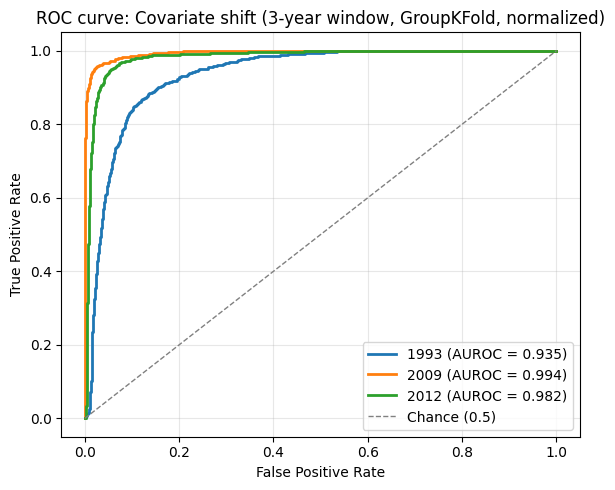

In [30]:
# Domain Classifier test for multivariate covariate shift + ROC/AUROC plot

from sklearn.model_selection import GroupKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

met_cols = [
    'tmmx_mean', 'rmax_mean', 'vs_mean', 'bi_mean', 'sph_mean', 'fm1000_mean',
    'srad_mean', 'erc_mean', 'vpd_mean', 'rmin_mean', 'pr_mean', 'fm100_mean',
    'etr_mean', 'pet_mean', 'tmmn_mean', 'th_mean'
]

df = gridmet_aug.copy()

clf = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

target_years = [1993, 2009, 2012]
window = 3
roc_data = {}

for yr in target_years:
    ref = df[(df['year'] >= yr - window) & (df['year'] <= yr - 1)][['id2', 'year'] + met_cols].dropna()
    mon = df[df['year'] == yr][['id2', 'year'] + met_cols].dropna()

    X = pd.concat([ref[met_cols], mon[met_cols]], axis=0).reset_index(drop=True)
    y = np.concatenate([np.zeros(len(ref), dtype=int), np.ones(len(mon), dtype=int)])
    groups = pd.concat([ref['id2'], mon['id2']], axis=0).reset_index(drop=True).values

    cv = GroupKFold(n_splits=5)

    print(f"\nYear {yr}  |  Ref window: [{yr-window}–{yr-1}] vs {yr}")
    print(f"Historical data: {len(ref)} | Test data: {len(mon)} | Total: {len(y)}")

    auc_scores = cross_val_score(
        clf, X, y,
        cv=cv,
        groups=groups,
        scoring="roc_auc"
    )

    print("Scores:", np.round(auc_scores, 4))
    print(f"Mean AUROC: {auc_scores.mean():.4f}  |  Std: {auc_scores.std():.4f}")

    y_scores = cross_val_predict(
        clf, X, y,
        cv=cv,
        groups=groups,
        method="predict_proba"
    )[:, 1]

    fpr, tpr, _ = roc_curve(y, y_scores)
    roc_auc = auc(fpr, tpr)

    roc_data[yr] = {"fpr": fpr, "tpr": tpr, "roc_auc": roc_auc}

plt.figure(figsize=(6, 5))
for yr in target_years:
    plt.plot(
        roc_data[yr]["fpr"],
        roc_data[yr]["tpr"],
        lw=2,
        label=f"{yr} (AUROC = {roc_data[yr]['roc_auc']:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--", lw=1, color="gray", label="Chance (0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC curve: Covariate shift ({window}-year window, GroupKFold, normalized)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

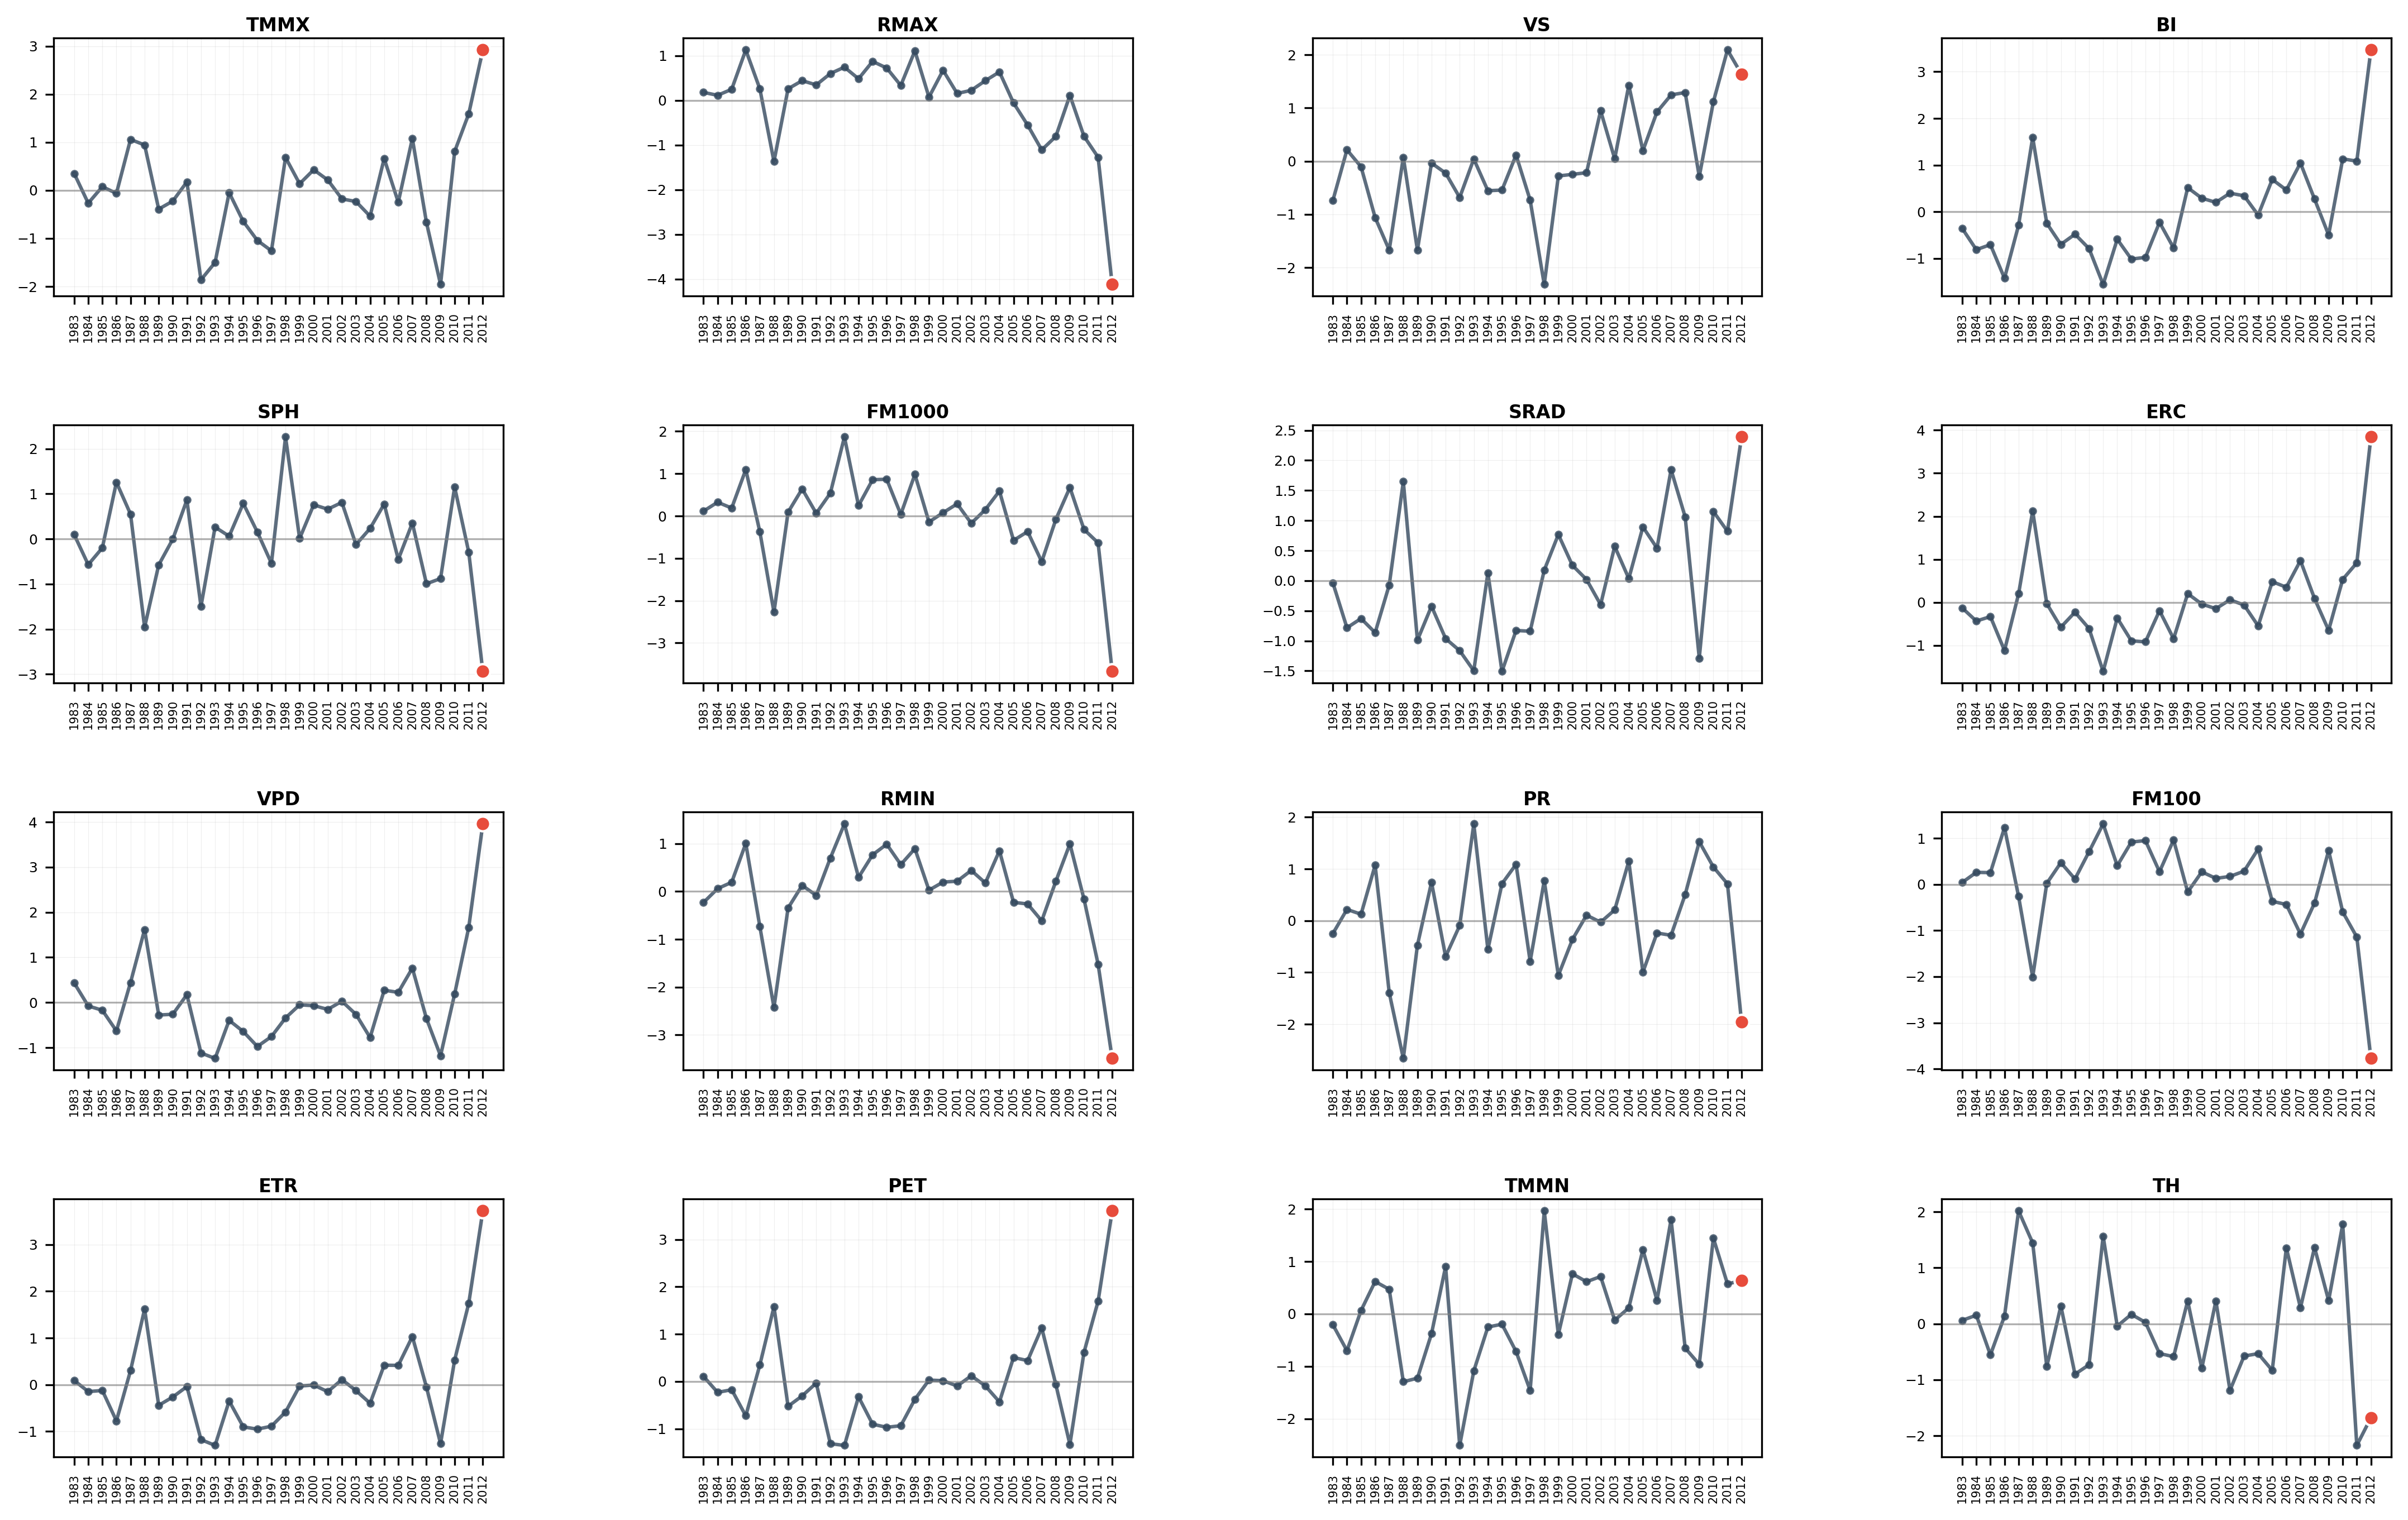

In [59]:
# Annual Weather Variables Time Series (annual mean features)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import StandardScaler

met_cols = [
    'tmmx_mean', 'rmax_mean', 'vs_mean', 'bi_mean', 'sph_mean', 'fm1000_mean',
    'srad_mean', 'erc_mean', 'vpd_mean', 'rmin_mean', 'pr_mean', 'fm100_mean',
    'etr_mean', 'pet_mean', 'tmmn_mean', 'th_mean'
]

colors = {
    'secondary': '#34495E',
    'accent1':   '#E74C3C'
}

df = gridmet_aug.copy()
df = df[df['year'] <= 2012][['id2', 'year'] + met_cols].dropna()

yearly_means = df.groupby('year')[met_cols].mean().sort_index()
years = yearly_means.index.values

# Standard scaling (z-score) per variable across years
scaler = StandardScaler()
yearly_std = pd.DataFrame(
    scaler.fit_transform(yearly_means),
    index=yearly_means.index,
    columns=met_cols
)

fig = plt.figure(figsize=(18, 11), dpi=300)
gs_small = GridSpec(4, 4, figure=fig, hspace=0.5, wspace=0.4)

# fig.text(
#     0.5, 0.98,
#     'Annual Mean Weather Variables',
#     fontsize=15, fontweight='bold', ha='center'
# )

for idx, col in enumerate(met_cols):
    ax = fig.add_subplot(gs_small[idx // 4, idx % 4])
    y = yearly_std[col]

    ax.plot(
        years, y.values,
        color=colors['secondary'],
        linewidth=1.5,
        marker='o',
        markersize=2.5,
        alpha=0.8
    )

    if 2012 in years:
        ax.scatter(
            2012, y.loc[2012],
            color=colors['accent1'],
            s=40,
            zorder=5,
            edgecolor='white',
            linewidth=1
        )

    ax.axhline(0, color='gray', linewidth=0.8, alpha=0.6)
    ax.set_title(col.replace('_mean', '').upper(), fontsize=8, fontweight='bold', pad=3)

    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=90, fontsize=5)
    ax.tick_params(axis='y', labelsize=6)

    ax.grid(True, alpha=0.2, linewidth=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    "Figures/paper-plots/annual_mean_features.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

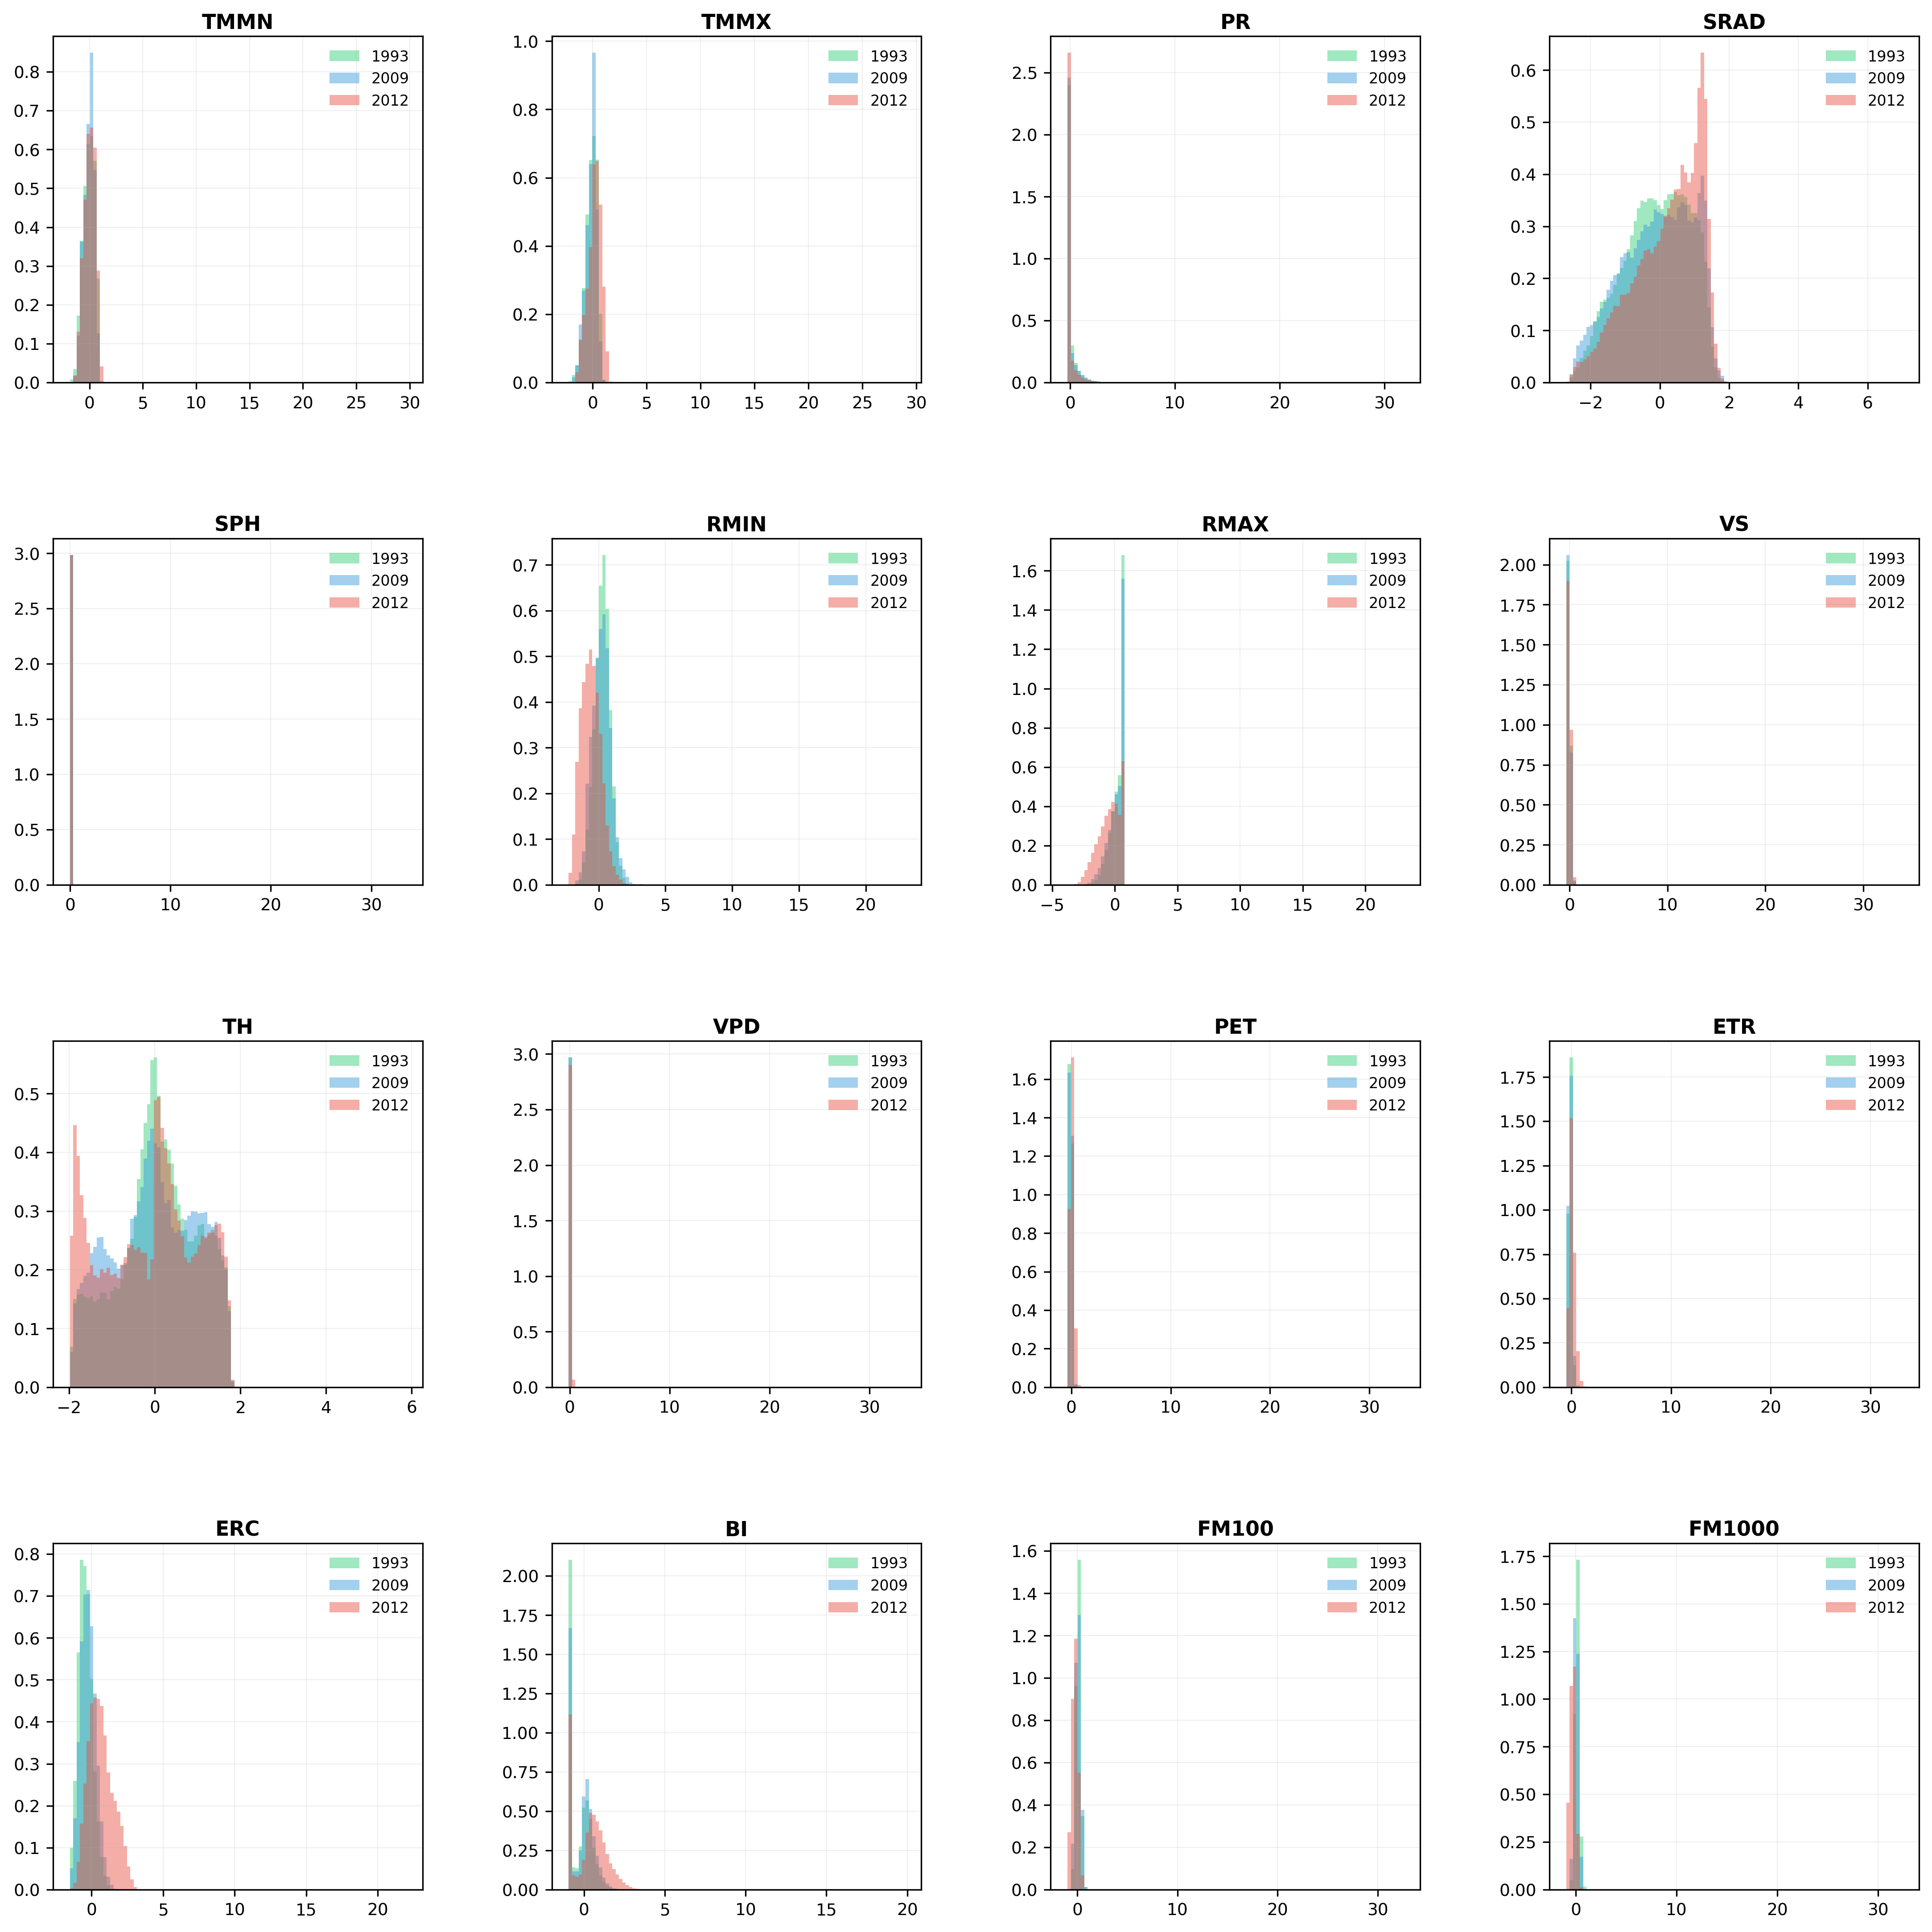

In [61]:
from matplotlib.gridspec import GridSpec
import numpy as np
import matplotlib.pyplot as plt

variables = ['tmmn', 'tmmx', 'pr', 'srad', 'sph', 'rmin',
             'rmax', 'vs', 'th', 'vpd', 'pet', 'etr', 'erc', 'bi', 'fm100', 'fm1000']

years_of_interest = [1993, 2009, 2012]

colors = {
    1993: '#2ECC71',
    2009: '#3498DB',
    2012: '#E74C3C'
}

df = gridmet_data.copy()
df = df[df['year'].isin(years_of_interest)]

fig = plt.figure(figsize=(18, 18), dpi=300)
gs = GridSpec(4, 4, figure=fig, hspace=0.45, wspace=0.35)

for idx, var in enumerate(variables):
    ax = fig.add_subplot(gs[idx // 4, idx % 4])

    var_cols = [c for c in df.columns if c.startswith(var + "-")]
    if not var_cols:
        ax.set_axis_off()
        continue

    # pooled values across counties, days, and years
    all_vals = df[var_cols].to_numpy().ravel()
    all_vals = all_vals[np.isfinite(all_vals)]

    mu = np.mean(all_vals)
    sigma = np.std(all_vals)

    # standardized pooled values (for shared bins)
    all_vals_std = (all_vals - mu) / sigma
    bins = np.histogram_bin_edges(all_vals_std, bins=100)

    for yr in years_of_interest:
        vals = df.loc[df['year'] == yr, var_cols].to_numpy().ravel()
        vals = vals[np.isfinite(vals)]

        # standardize using pooled mean/std
        vals_std = (vals - mu) / sigma

        ax.hist(
            vals_std,
            bins=bins,
            density=True,
            alpha=0.45,
            color=colors[yr],
            label=str(yr),
            edgecolor='none'
        )

    ax.set_title(var.upper(), fontsize=11, fontweight='bold', pad=4)
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(True, alpha=0.25, linewidth=0.4)

    ax.legend(fontsize=8, frameon=False, loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

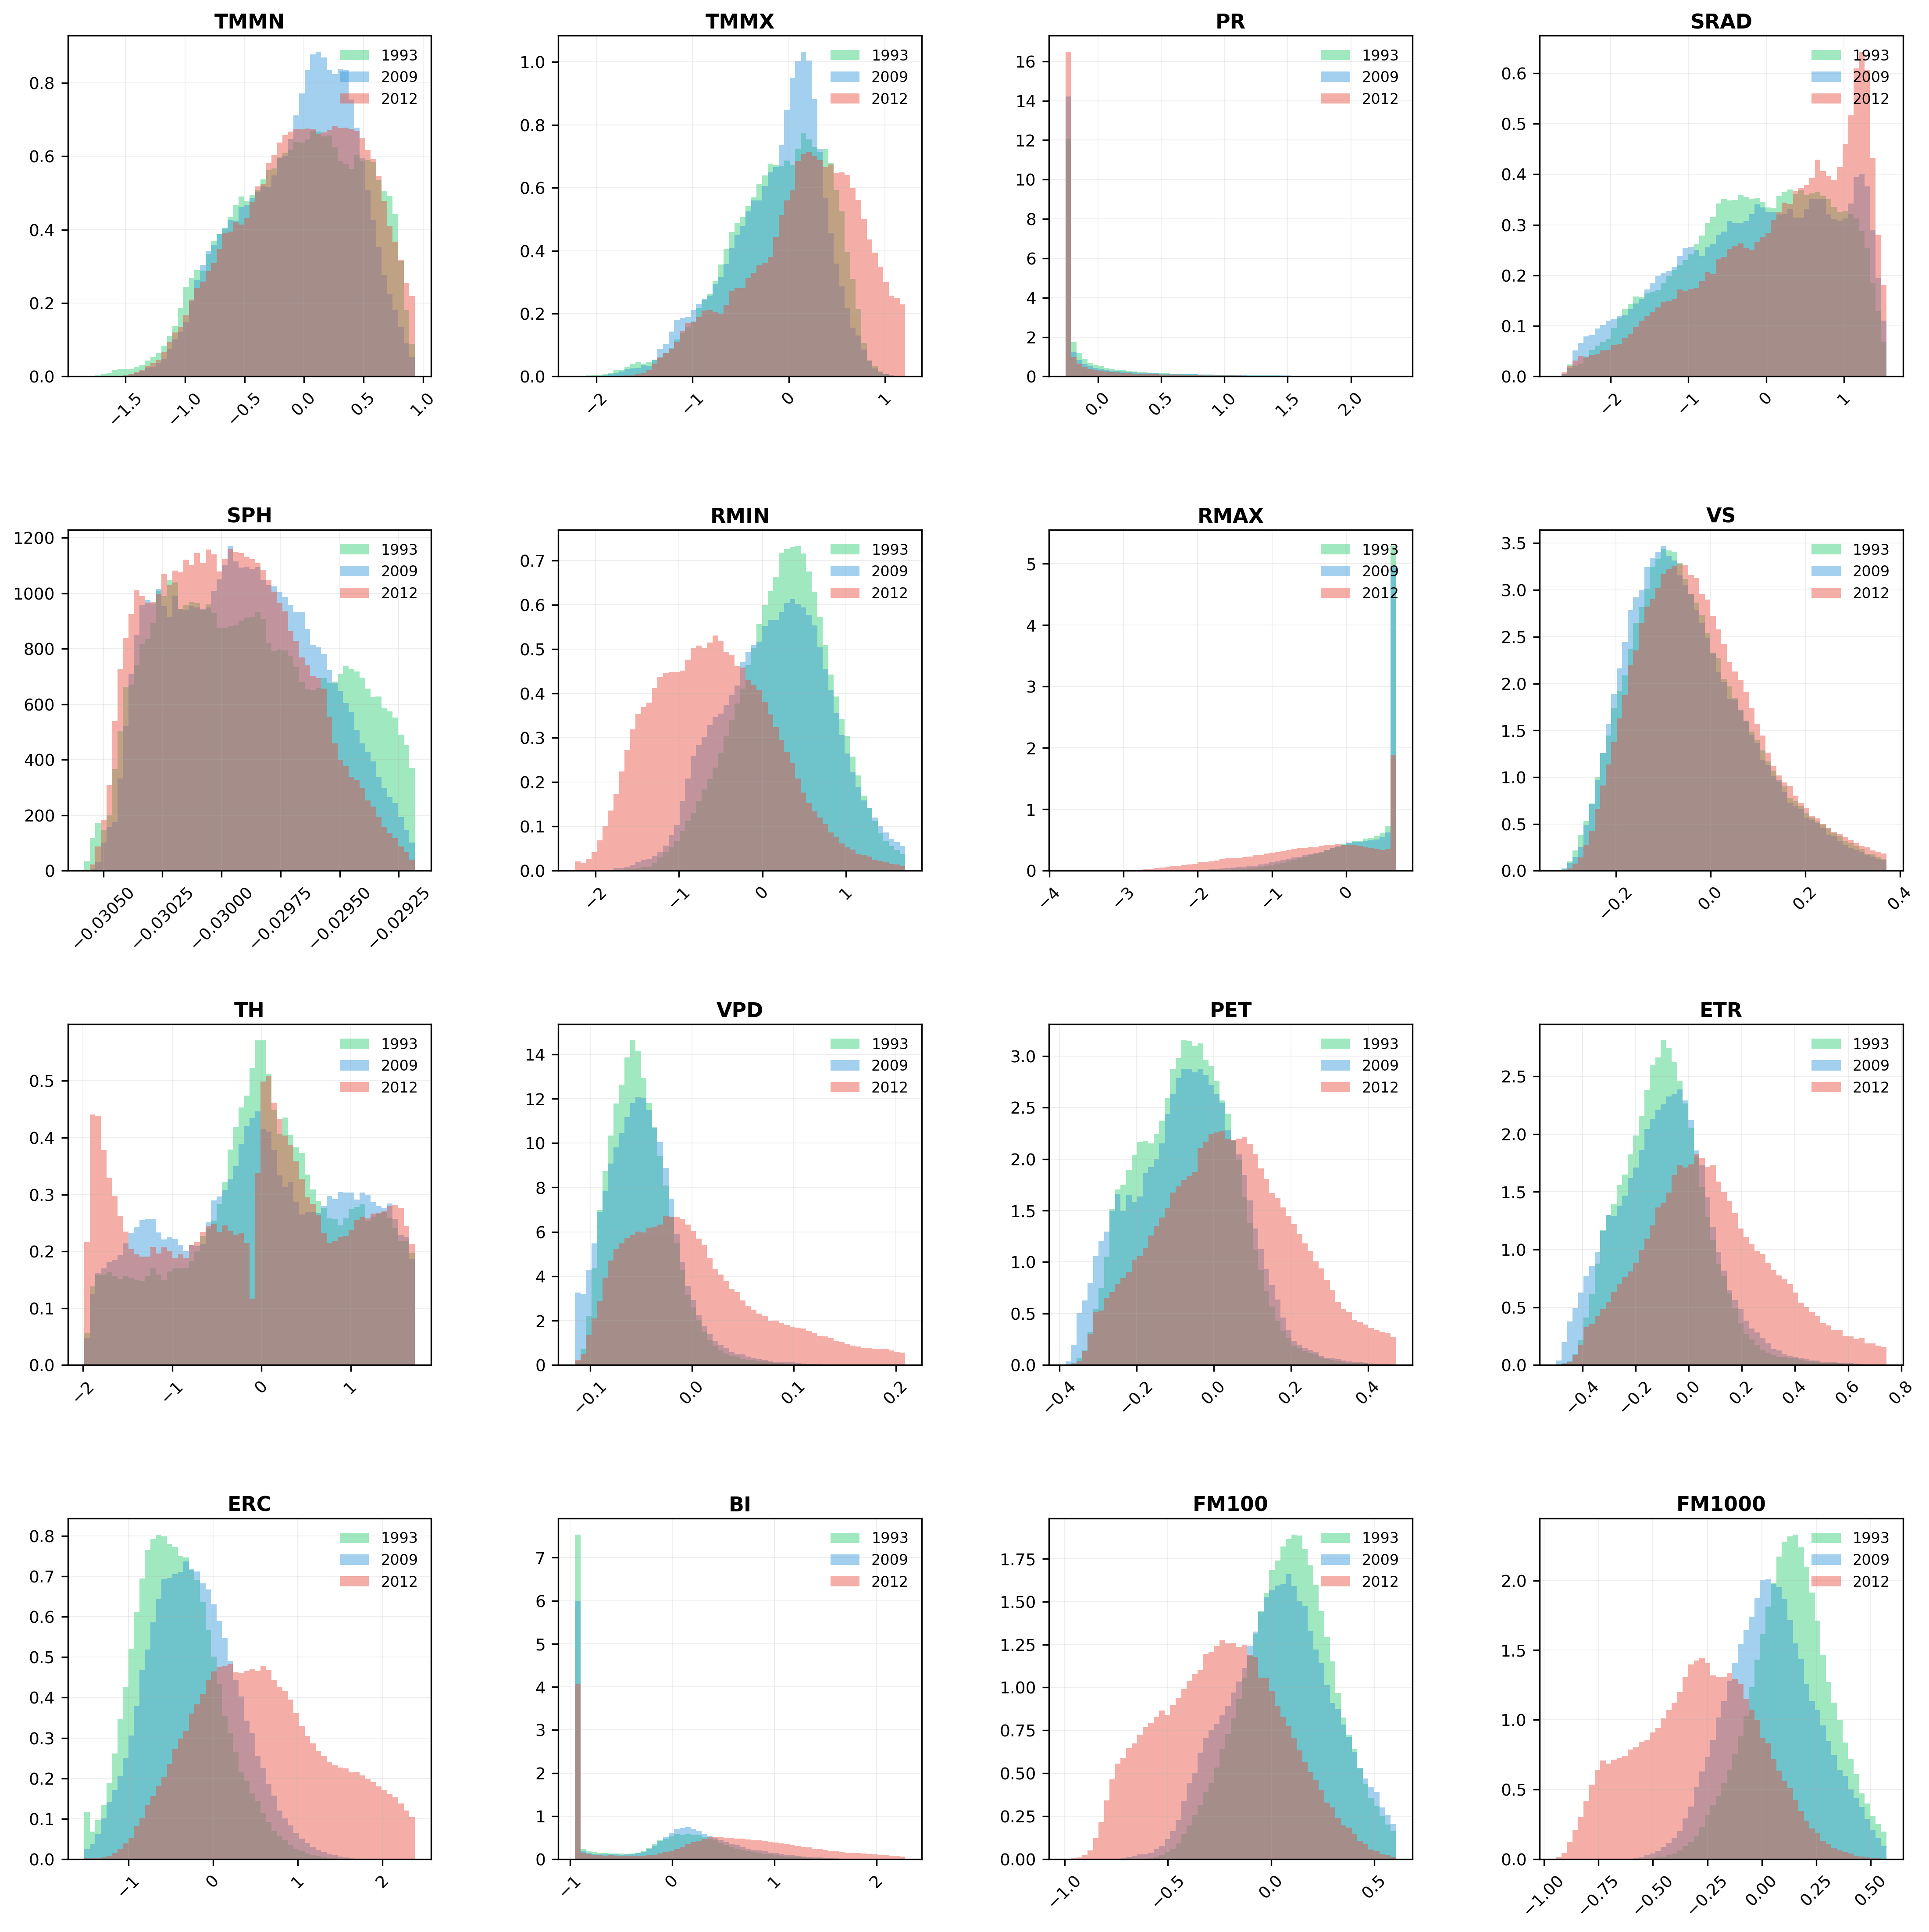

In [66]:
from matplotlib.gridspec import GridSpec

variables = ['tmmn', 'tmmx', 'pr', 'srad', 'sph', 'rmin',
             'rmax', 'vs', 'th', 'vpd', 'pet', 'etr', 'erc', 'bi', 'fm100', 'fm1000']

years_of_interest = [1993, 2009, 2012]

colors = {
    1993: '#2ECC71',
    2009: '#3498DB',
    2012: '#E74C3C'
}

df = gridmet_data.copy()
df = df[df['year'].isin(years_of_interest)]

fig = plt.figure(figsize=(18, 18), dpi=300)
gs = GridSpec(4, 4, figure=fig, hspace=0.45, wspace=0.35)

for idx, var in enumerate(variables):
    ax = fig.add_subplot(gs[idx // 4, idx % 4])

    var_cols = [c for c in df.columns if c.startswith(var + "-")]
    if not var_cols:
        ax.set_axis_off()
        continue

    # pooled raw values
    all_vals = df[var_cols].to_numpy().ravel()
    all_vals = all_vals[np.isfinite(all_vals)]

    # pooled standardization
    mu = np.mean(all_vals)
    sigma = np.std(all_vals)

    all_vals_std = (all_vals - mu) / sigma

    # clipping between 
    lo, hi = np.percentile(all_vals_std, [0, 99])
    all_vals_std = all_vals_std[(all_vals_std >= lo) & (all_vals_std <= hi)]
    bins = np.histogram_bin_edges(all_vals_std, bins=60)

    for yr in years_of_interest:
        vals = df.loc[df['year'] == yr, var_cols].to_numpy().ravel()
        vals = vals[np.isfinite(vals)]

        vals_std = (vals - mu) / sigma
        vals_std = vals_std[(vals_std >= lo) & (vals_std <= hi)]

        ax.hist(
            vals_std,
            bins=bins,
            density=True,
            alpha=0.45,
            color=colors[yr],
            label=str(yr),
            edgecolor='none'
        )

    ax.set_title(var.upper(), fontsize=11, fontweight='bold', pad=4)
    ax.tick_params(axis='x', labelsize=9, labelrotation=45)  
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(True, alpha=0.25, linewidth=0.4)
    ax.legend(fontsize=8, frameon=False, loc='upper right')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(
    "Figures/paper-plots/density_plot.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()